In [165]:
import pandas as pd
import numpy as np
from sqlalchemy.dialects.mssql.information_schema import columns
from transformers.utils.fx import torch_abs

In [166]:
df_test = pd.read_csv('datasets/real data/yjmob100k-dataset1.csv')
df_test
# df_test.head(400)

,uid,d,t,x,y
0,0,0,1,79,86
1,0,0,2,79,86
2,0,0,8,77,86
3,0,0,9,77,86
4,0,0,19,81,89
...,...,...,...,...,...
111535170,99999,74,38,119,77
111535171,99999,74,39,132,94
111535172,99999,74,40,124,105
111535173,99999,74,41,121,107


In [167]:
visit_counts = df_test.groupby(['x', 'y'])['uid'].nunique().reset_index(name =  'count')

visit_counts
#
#
# total_flows= total_flows.rename(columns= {'flow_sum' : 'total_flow'})
# df_merged_pop = df_merged_pop.merge(total_flows, on=['origin_msoa11cd', 'destination_msoa11cd'], how='left')
#
#
#
#
# df_cleaned = df_test.drop(columns=['d', 't'])
# df_cleaned = df_cleaned.dropduplicates

,x,y,count
0,1,1,199
1,1,2,78
2,1,3,47
3,1,4,86
4,1,5,163
...,...,...,...
34027,200,196,238
34028,200,197,76
34029,200,198,92
34030,200,199,197


In [168]:
import pandas as pd
from sklearn.cluster import KMeans

In [169]:
# Extract the coordinates (features) and the activity (weights)
coords = visit_counts[['x', 'y']]
weights = visit_counts['count']

# Decide how many pseudo-zip-codes you want for the whole city
num_zipcodes = 200 # assumuing population is liek 2 -3 mill form around 5% sampling rate an 10k ppl per zipcode
kmeans = KMeans(n_clusters=num_zipcodes, random_state=42)

# Fit the model
kmeans.fit(coords)

# The model generates a label (e.g., 0 to 99) for each cell.
# Let's save that label into our table as the new "zipcode"
visit_counts['zipcode'] = kmeans.labels_

In [170]:
visit_counts

,x,y,count,zipcode
0,1,1,199,172
1,1,2,78,172
2,1,3,47,172
3,1,4,86,172
4,1,5,163,172
...,...,...,...,...
34027,200,196,238,175
34028,200,197,76,175
34029,200,198,92,175
34030,200,199,197,175


In [171]:
df_zipcodes = df_test.copy()
df_zipcodes = df_zipcodes.merge(visit_counts[['x', 'y', 'zipcode']], left_on=['x', 'y'], right_on=['x', 'y'], how='left')
df_zipcodes = df_zipcodes.drop(columns = ['x', 'y'])

In [172]:
zip_code_counts = visit_counts['zipcode'].value_counts()
zip_code_areas = ((zip_code_counts * 250000)/ 1e6) *  0.386 #sq mileas

df_zipcodes_area = df_zipcodes.copy()
df_zipcodes_area = df_zipcodes_area.merge(zip_code_areas, left_on='zipcode', right_on='zipcode', how='left')
df_zipcodes_area = df_zipcodes_area.rename(columns= {'count' : 'area'})


In [173]:
df_zipcodes_area

,uid,d,t,zipcode,area
0,0,0,1,117,16.5015
1,0,0,2,117,16.5015
2,0,0,8,48,19.7825
3,0,0,9,48,19.7825
4,0,0,19,117,16.5015
...,...,...,...,...,...
111535170,99999,74,38,67,18.0455
111535171,99999,74,39,146,16.6945
111535172,99999,74,40,27,19.5895
111535173,99999,74,41,129,16.4050


In [174]:
df_testing = df_zipcodes_area.copy()
df_testing = df_testing[~((df_testing['t'] >= 40) | (df_testing['t'] <= 12))]

In [175]:
# df_sorted = df_zipcodes_area.sort_values(by= ['uid', 'd', 't'])
df_sorted = df_testing.sort_values(by= ['uid', 'd', 't'])


In [176]:
df_sorted = df_sorted.rename(columns = {'zipcode' : 'zip_org'})
df_sorted['zip_dest'] = df_sorted.groupby(['uid', 'd'])['zip_org'].shift(-1)
df_sorted = df_sorted.dropna(subset=['zip_dest'])
df_sorted = df_sorted.drop(columns = ['uid', 'd', 't'])


In [177]:
df_sorted

,zip_org,area,zip_dest
4,117,16.5015,117.0
5,117,16.5015,117.0
6,117,16.5015,117.0
7,117,16.5015,48.0
8,48,19.7825,119.0
...,...,...,...
111535166,178,18.2385,93.0
111535167,93,16.1155,127.0
111535168,127,19.1070,178.0
111535169,178,18.2385,67.0


In [178]:
df_testing

,uid,d,t,zipcode,area
4,0,0,19,117,16.5015
5,0,0,20,117,16.5015
6,0,0,21,117,16.5015
7,0,0,22,117,16.5015
8,0,0,24,48,19.7825
...,...,...,...,...,...
111535167,99999,74,19,93,16.1155
111535168,99999,74,35,127,19.1070
111535169,99999,74,36,178,18.2385
111535170,99999,74,38,67,18.0455


In [179]:
total_flows = df_sorted[['zip_org', 'zip_dest']].value_counts().reset_index(name ='flow')
total_flows['flow'] = total_flows['flow'] / 75
total_flows

,zip_org,zip_dest,flow
0,78,78.0,36257.253333
1,86,86.0,25699.013333
2,51,51.0,18145.266667
3,146,146.0,16865.040000
4,29,29.0,16299.893333
...,...,...,...
21121,158,99.0,0.013333
21122,4,148.0,0.013333
21123,158,107.0,0.013333
21124,97,35.0,0.013333


In [180]:
test = df_test.copy()

num_unique_cells = len(test[['x', 'y']].drop_duplicates())
num_unique_cells

34032

In [194]:
population = (total_flows.groupby('zip_org')['flow'].sum()).reset_index(name = 'population')
population['population'] = population['population'].clip(lower=80)
df_flows_pop = total_flows.merge(population, on='zip_org', how='left')


zip_code_counts = visit_counts['zipcode'].value_counts()
zip_code_areas = ((zip_code_counts * 250000)/ 1e6) *  0.386 #sq mileas

df_flows_pop_area = df_flows_pop.copy()
df_flows_pop_area = df_flows_pop_area.merge(zip_code_areas, left_on='zip_org', right_on='zipcode', how='left')
df_flows_pop_area = df_flows_pop_area.rename(columns= {'count' : 'area'})

df_flows_pop_area

,zip_org,zip_dest,flow,population,area
0,78,78.0,36257.253333,53674.920000,18.1420
1,86,86.0,25699.013333,39867.520000,19.4930
2,51,51.0,18145.266667,24791.480000,21.2300
3,146,146.0,16865.040000,25637.693333,16.6945
4,29,29.0,16299.893333,24165.506667,17.4665
...,...,...,...,...,...
21121,158,99.0,0.013333,9986.840000,16.2120
21122,4,148.0,0.013333,3449.680000,16.3085
21123,158,107.0,0.013333,9986.840000,16.2120
21124,97,35.0,0.013333,151.346667,12.4485


In [195]:
population

,zip_org,population
0,0,80.000000
1,1,20216.106667
2,2,224.480000
3,3,1356.146667
4,4,3449.680000
...,...,...
195,195,6431.346667
196,196,2879.386667
197,197,1672.333333
198,198,11992.373333


In [196]:

# 1. Create integer index mapping for nodes

df_cleaned = df_flows_pop_area.copy()
df_cleaned['zip_dest'] = df_cleaned['zip_dest'].astype(int)
df_cleaned['flow'] = df_cleaned['flow'].astype(int)
df_cleaned['population'] = df_cleaned['population'].astype(int)

df_cleaned = df_cleaned[df_cleaned['zip_dest'].isin(df_cleaned['zip_org'].unique())] #make sure not destination only nodes



all_nodes = pd.concat([df_cleaned['zip_org'], df_cleaned['zip_dest']]).unique()
node_to_idx = {node: idx for idx, node in enumerate(all_nodes)}
number_nodes = len(all_nodes)

ordered_geoids = [geoid for geoid, idx in sorted(node_to_idx.items(), key=lambda x: x[1])]

# 3. Area — one area per geoid_o, reindex to same order
area_distr = (df_cleaned.drop_duplicates('zip_org')
                .set_index('zip_org')['area']
                .reindex(ordered_geoids)
                .fillna(0)
                .values)

ordered_geoids

[78,
 86,
 51,
 146,
 29,
 124,
 1,
 149,
 27,
 67,
 11,
 181,
 178,
 112,
 131,
 12,
 65,
 59,
 155,
 167,
 127,
 9,
 169,
 49,
 198,
 138,
 125,
 47,
 150,
 58,
 110,
 158,
 77,
 129,
 13,
 48,
 192,
 171,
 194,
 45,
 95,
 101,
 144,
 111,
 117,
 14,
 195,
 132,
 60,
 139,
 114,
 20,
 22,
 152,
 164,
 76,
 113,
 18,
 38,
 99,
 120,
 182,
 119,
 84,
 106,
 6,
 143,
 36,
 33,
 92,
 107,
 193,
 141,
 15,
 21,
 102,
 28,
 35,
 116,
 75,
 23,
 96,
 81,
 72,
 130,
 32,
 183,
 172,
 69,
 93,
 25,
 165,
 162,
 73,
 135,
 189,
 4,
 157,
 168,
 55,
 71,
 196,
 79,
 70,
 175,
 173,
 166,
 83,
 122,
 62,
 56,
 53,
 52,
 104,
 82,
 108,
 41,
 40,
 24,
 3,
 63,
 148,
 170,
 197,
 16,
 64,
 153,
 161,
 39,
 8,
 128,
 137,
 94,
 44,
 147,
 140,
 188,
 187,
 30,
 115,
 54,
 105,
 126,
 80,
 87,
 91,
 10,
 190,
 136,
 100,
 98,
 179,
 17,
 5,
 191,
 186,
 109,
 90,
 103,
 199,
 68,
 37,
 177,
 46,
 2,
 159,
 97,
 42,
 31,
 163,
 121,
 160,
 142,
 151,
 74,
 123,
 85,
 26,
 180,
 50,
 0,
 154,
 19,
 57

In [197]:
import numpy as np
from scipy.sparse import coo_matrix


rows = df_cleaned['zip_org'].map(node_to_idx).values
cols = df_cleaned['zip_dest'].map(node_to_idx).values

# 3. Compute weight = fraction of origin population that flows to destination
#    pop_flows / total_pop gives: "X% of node i's population goes to node j"
weights = (df_cleaned['flow'] / df_cleaned['population']).values

# 4. Build sparse matrix
graph = coo_matrix((weights, (rows, cols)), shape=(number_nodes, number_nodes))
#graph = graph.tocsr()

weights
#df_merged_pop

array([0.67550397, 0.64461836, 0.73191884, ..., 0.        , 0.        ,
       0.        ])

In [185]:
# import scipy.sparse as sp
#
# # Assuming 'graph' is your csr_matrix
# sp.save_npz('testing graphs/mobility_graph_lond.npz', graph)

In [186]:
# print("node_to_idx size:", len(node_to_idx))
# print("unique geoid_o in df_merged_pop:", df_merged_pop['origin_msoa11cd'].nunique())
# print("unique geoid_d in df_merged_pop:", df_merged_pop['destination_msoa11cd'].nunique())
#
# # Find the offending node
# in_idx_not_in_origins = set(node_to_idx.keys()) - set(df_merged_pop['origin_msoa11cd'].unique())
# print("nodes in graph but not in origins:", in_idx_not_in_origins)

In [187]:
def calculte_m(area_distr, eff_population, graph, mobility_rate):
    c = 2e-4
    f =  2 - np.exp(-c*(eff_population / area_distr))

    f_neff = f / eff_population

    #m1 and m2 are 0 if p=1

    m1 = ((1-mobility_rate) **2) * f_neff
    m1 = np.diag(m1) #kronegers thing makes it a diagonal


    #r_ij multipleid by f/neff_j
    term_1 = graph.multiply(f_neff[np.newaxis, :])
    #r_ji (same as transpose term 1)
    term_2 = graph.T.multiply(f_neff[:, np.newaxis])
    m2 = mobility_rate * (1-mobility_rate) * (term_1 + term_2).toarray()

    #ril * nf_neff is same as term 1, then matrix mult with transpose to get m3
    m3= (mobility_rate**2) * (term_1 @ graph.T).toarray()

    return m1 + m2 + m3

In [208]:
from scipy.linalg import eig

def generate_data(input_graph,input_area_distr, recovery_rate, population, mobility_rate = 1,):
    graph = input_graph
    #visualise_graph(graph)

        #calculat eff population formula 6 from papaer

    eff_population = (1 - mobility_rate) * population + mobility_rate * np.array(graph.T.dot(population)).flatten()
    eff_population[eff_population == 0] = 1

    #devide area acording to log-linear dist

    area_distr = input_area_distr
    area_distr[area_distr == 0] = 1




    matrix_m = calculte_m(area_distr, eff_population, graph, 1)
    matrix_m = matrix_m * population[np.newaxis, :]

     # --- diagnostics ---
    print("area_distr NaNs:", np.isnan(area_distr).sum(), "zeros:", (area_distr == 0).sum())
    print("eff_population NaNs:", np.isnan(eff_population).sum())
    print("population NaNs:", np.isnan(population).sum())
    print("matrix_m NaNs:", np.isnan(matrix_m).sum(), "Infs:", np.isinf(matrix_m).sum())

    eigenvalues, _ = eig(matrix_m)
    spectral_radius = np.max(np.abs(eigenvalues))


    # -------------------

    # matrix_m_2 = calculte_m(area_distr, eff_population, graph, 0)
    #
    # eigenvalues_2, _ = eigs(matrix_m_2, k=1, which='LM')
    # spectral_radius_2 = np.abs(eigenvalues_2[0])

    print(spectral_radius)
    # print(spectral_radius_2)



    print(recovery_rate / spectral_radius)
    return recovery_rate / spectral_radius


population = (df_cleaned.drop_duplicates('zip_org')
                           .set_index('zip_org')['population']
                           .reindex(ordered_geoids)
                           .fillna(0)
                           .astype(float)
                           .values) * 5.5
threshold = generate_data(graph, area_distr, 1, population, 1)




area_distr NaNs: 0 zeros: 0
eff_population NaNs: 0
population NaNs: 0
matrix_m NaNs: 0 Infs: 0
1.6370585447371455
0.6108517030223651


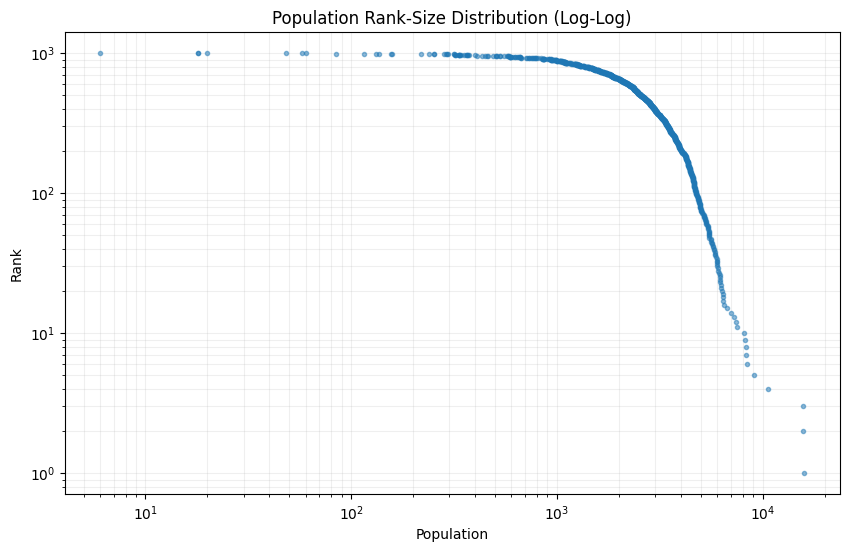

In [106]:
import matplotlib.pyplot as plt
import numpy as np

# Sort population from largest to smallest
sorted_pop = np.sort(population)[::-1]
ranks = np.arange(1, len(sorted_pop) + 1)

plt.figure(figsize=(10, 6))
plt.loglog(sorted_pop, ranks, marker='.', linestyle='none', alpha=0.5)
plt.title("Population Rank-Size Distribution (Log-Log)")
plt.ylabel("Rank")
plt.xlabel("Population")
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

In [200]:
area_distr.sum()

3284.0879999999997

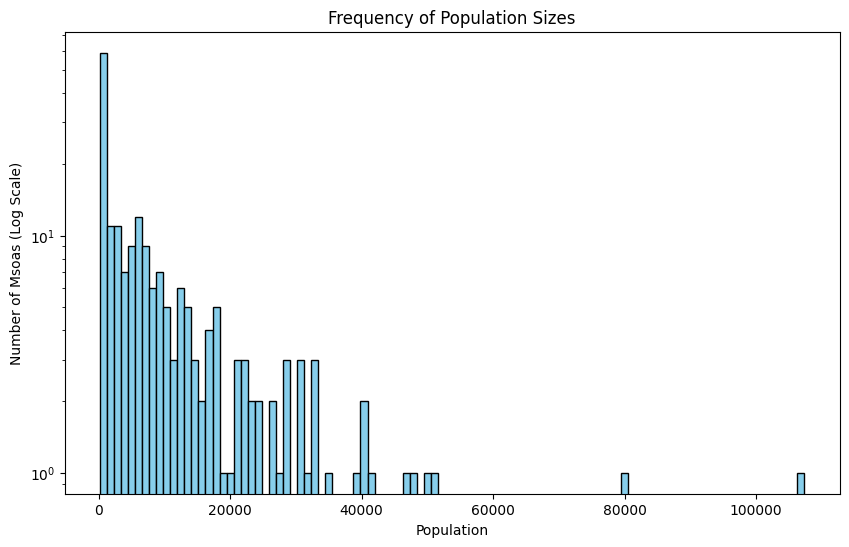

In [199]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(population, bins=100, color='skyblue', edgecolor='black', log=True)
plt.title("Frequency of Population Sizes")
plt.xlabel("Population")
plt.ylabel("Number of Msoas (Log Scale)")
plt.show()

In [205]:
population.max()

268370.0

In [95]:
# np.savez_compressed('testing graphs/mobility_metadata_real.npz',
#                     population=population)

In [209]:

import torch
from torch_geometric.data import Data
import numpy as np
import os


position_array = np.zeros((number_nodes, 2))
edge_index = torch.tensor(np.vstack((graph.row, graph.col)), dtype=torch.long)

# 2. edge_attr: Shape [num_edges, 1], type float32
edge_attr = torch.tensor(graph.data, dtype=torch.float32).view(-1, 1)

# 3. x (Node features): Combine population and position, Shape [num_nodes, 3], type float32
node_features = np.column_stack((population, area_distr, position_array))
x = torch.tensor(node_features, dtype=torch.float32)

# 4. y (Target label): Shape [1], type float32
y = torch.tensor([threshold], dtype=torch.float32)

# --- Construct PyG Data Object ---
data_obj = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)

# Append to our list
pyg_graph = data_obj

save_path = '/Users/emmapinckers/PycharmProjects/thesis/data generation/datasets/version1/japan_data.pt'

torch.save(pyg_graph, save_path)


